# Neural Networks

## 1. From Perceptron to MLP

In this section we'll make a brief summary of the history of neural networks that will allow us to better understand both how they work and how to define them in code.

### Perceptron (Rosenblatt, 1958)

The basic unit of a neural network is called a perceptron. Like other models, it receives *n* inputs, then weights them, applies an activation function, and produces a binary output. Its formulation is as follows:

$$y = f\left(\sum_{i=1}^{n} w_i x_i + b\right).$$

Where $x_i$ represents the value of the $i$-th input (a feature of the sample); $w_i$ is the weight associated with input $i$, indicating the relative importance of each input. $b$ is the bias term, which allows the output to be adjusted independently of the inputs; and $n$ is the total number of inputs. Finally, $f$ is the activation function (in the original perceptron, the _Heaviside_ step function), which ensures that the perceptron output $y$ is either 0 or 1.


This model has a key limitation, as it can only separate linearly separable classes. For example, it cannot solve the XOR problem.

### Multi-Layer Perceptron (MLP)

The solution to the perceptron's limitation is to concatenate different perceptrons forming different layers with non-linear activation functions, which allows solving more complex problems. Its architecture consists of three types of layers:

- **Input layer**: Where features are received, the number of neurons in this layer must match the number of features.
- **Hidden layers**: Contain sets of perceptrons. The number of hidden layers and their number of neurons is a hyperparameter that we need to discover for each problem
- **Output layer**: The one that provides the final result. The number of neurons will depend on the nature of the problem and the activation function we need or want to use.

![RNN](../../_static/02/MultiLayerPerceptron2.png "MLP")

Its formulation is as follows:

$$h = f(W \cdot x + b) \quad \text{(hidden layer).}$$

Where, $x$ is the input vector (the *features* of the sample), $W$ is the weight matrix of the layer; each element $w_{ij}$ connects neuron $j$ of the previous layer with neuron $i$ of the current layer. $b$ is the bias vector; it allows shifting the activation function independently of the input. $f$ is the activation function. $h$ is the output vector of the hidden layer (known as *hidden state*).

$$\hat{y} = g(V \cdot h + c) \quad \text{(output layer).}$$

Where, $V$ is the weight matrix of the output layer; $c$ is the bias vector of the output layer. $g$ is the activation function of the output layer. Finally, $\hat{y}$ is the network's prediction.


When designing and making decisions about the architecture of our MLPs, we can think of the **Universal Approximation Theorem** which tells us that an MLP with a single sufficiently large hidden layer can approximate any continuous function. In practice, it has been shown that deeper networks learn more efficient representations.


## 2. Activation Functions

As mentioned earlier, activation functions introduce the non-linearity that allows the network to learn complex representations. Without them, an MLP would be equivalent to linear regression.

Below we explain the most used ones:

- **ReLU:** Function used by default in hidden layers. $$ReLU(x) = \max(0, x).$$
- **Sigmoid:** Output function useful for binary classification. $$\sigma(x) = \frac{1}{1 + e^{-x}} \quad \text{output} \in (0, 1).$$
- **Softmax:** Multi-class classification output function. $$\sigma(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}.$$
- **Tanh:** Function used in hidden layers in recurrent networks. $$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} \quad \text{output} \in (-1, 1).$$


## 3. Training Steps

A training cycle (also called an epoch) consists of iterating over the data set and updating the weights of the network (previously defined as $W$). Each iteration of this cycle follows the following four steps:

### Step 1 — Forward Pass
Data passes through the network layer by layer from the input layer, passing through the hidden layers to get the prediction $\hat{y}$.

### Step 2 — Loss Calculation
The error between $\hat{y}$ and the actual value $y$ is quantified using a loss function. The choice depends on the type of problem.

#### Regression

- **Mean Squared Error (MSE):** this function penalizes large errors quadratically. A double error has four times more weight. Sensitive to *outliers*. It is convenient to use it when large errors are especially undesirable and the data does not have many outliers. Its formula is as follows:
$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2.$$

- **Mean Absolute Error (MAE):** this function penalizes all errors proportionally, regardless of their magnitude. More robust to *outliers* than MSE. It is convenient to use it when data has outliers or when you want a direct interpretation in the original units. Its formula is as follows:

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|.$$


#### Classification

- **Binary Cross-Entropy (BCE):** measures the difference between the predicted and actual probability distribution. It strongly penalizes very confident but incorrect predictions. It is used in binary classification problems (labels 0/1). The output layer must use a Sigmoid function. Its formula is as follows: $$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right].$$

- **Categorical Cross-Entropy:** generalization of $BCE$ for $C$ classes. Only the correct class contributes to the loss calculation for each sample. Used in multi-class classification problems. The output layer should use Softmax. Its formula is as follows:
$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{c=1}^{C} y_{ic} \log(\hat{y}_{ic}).$$


### Step 3 — Backward Pass (Backpropagation)
The gradient of the loss with respect to each weight is calculated using the chain rule.

### Step 4 — Weight Update (*optimizer step*)
The optimizer (SGD, Adam...) modifies the weights in the direction that minimizes the loss: $w \leftarrow w - \eta \cdot \nabla L$.

Where $\eta$ is a hyperparameter with a value between 0 and 1, known as the learning rate which measures how the network's weights are updated. A value too large causes the network not to converge, and a value too small causes it to learn very slowly.

Computing an epoch involves performing this cycle over the entire training set. In practice, training is done by dividing the training set into parts (known as *batches*) for computational efficiency and for an implicit regularization effect (Stochastic Gradient Descent).
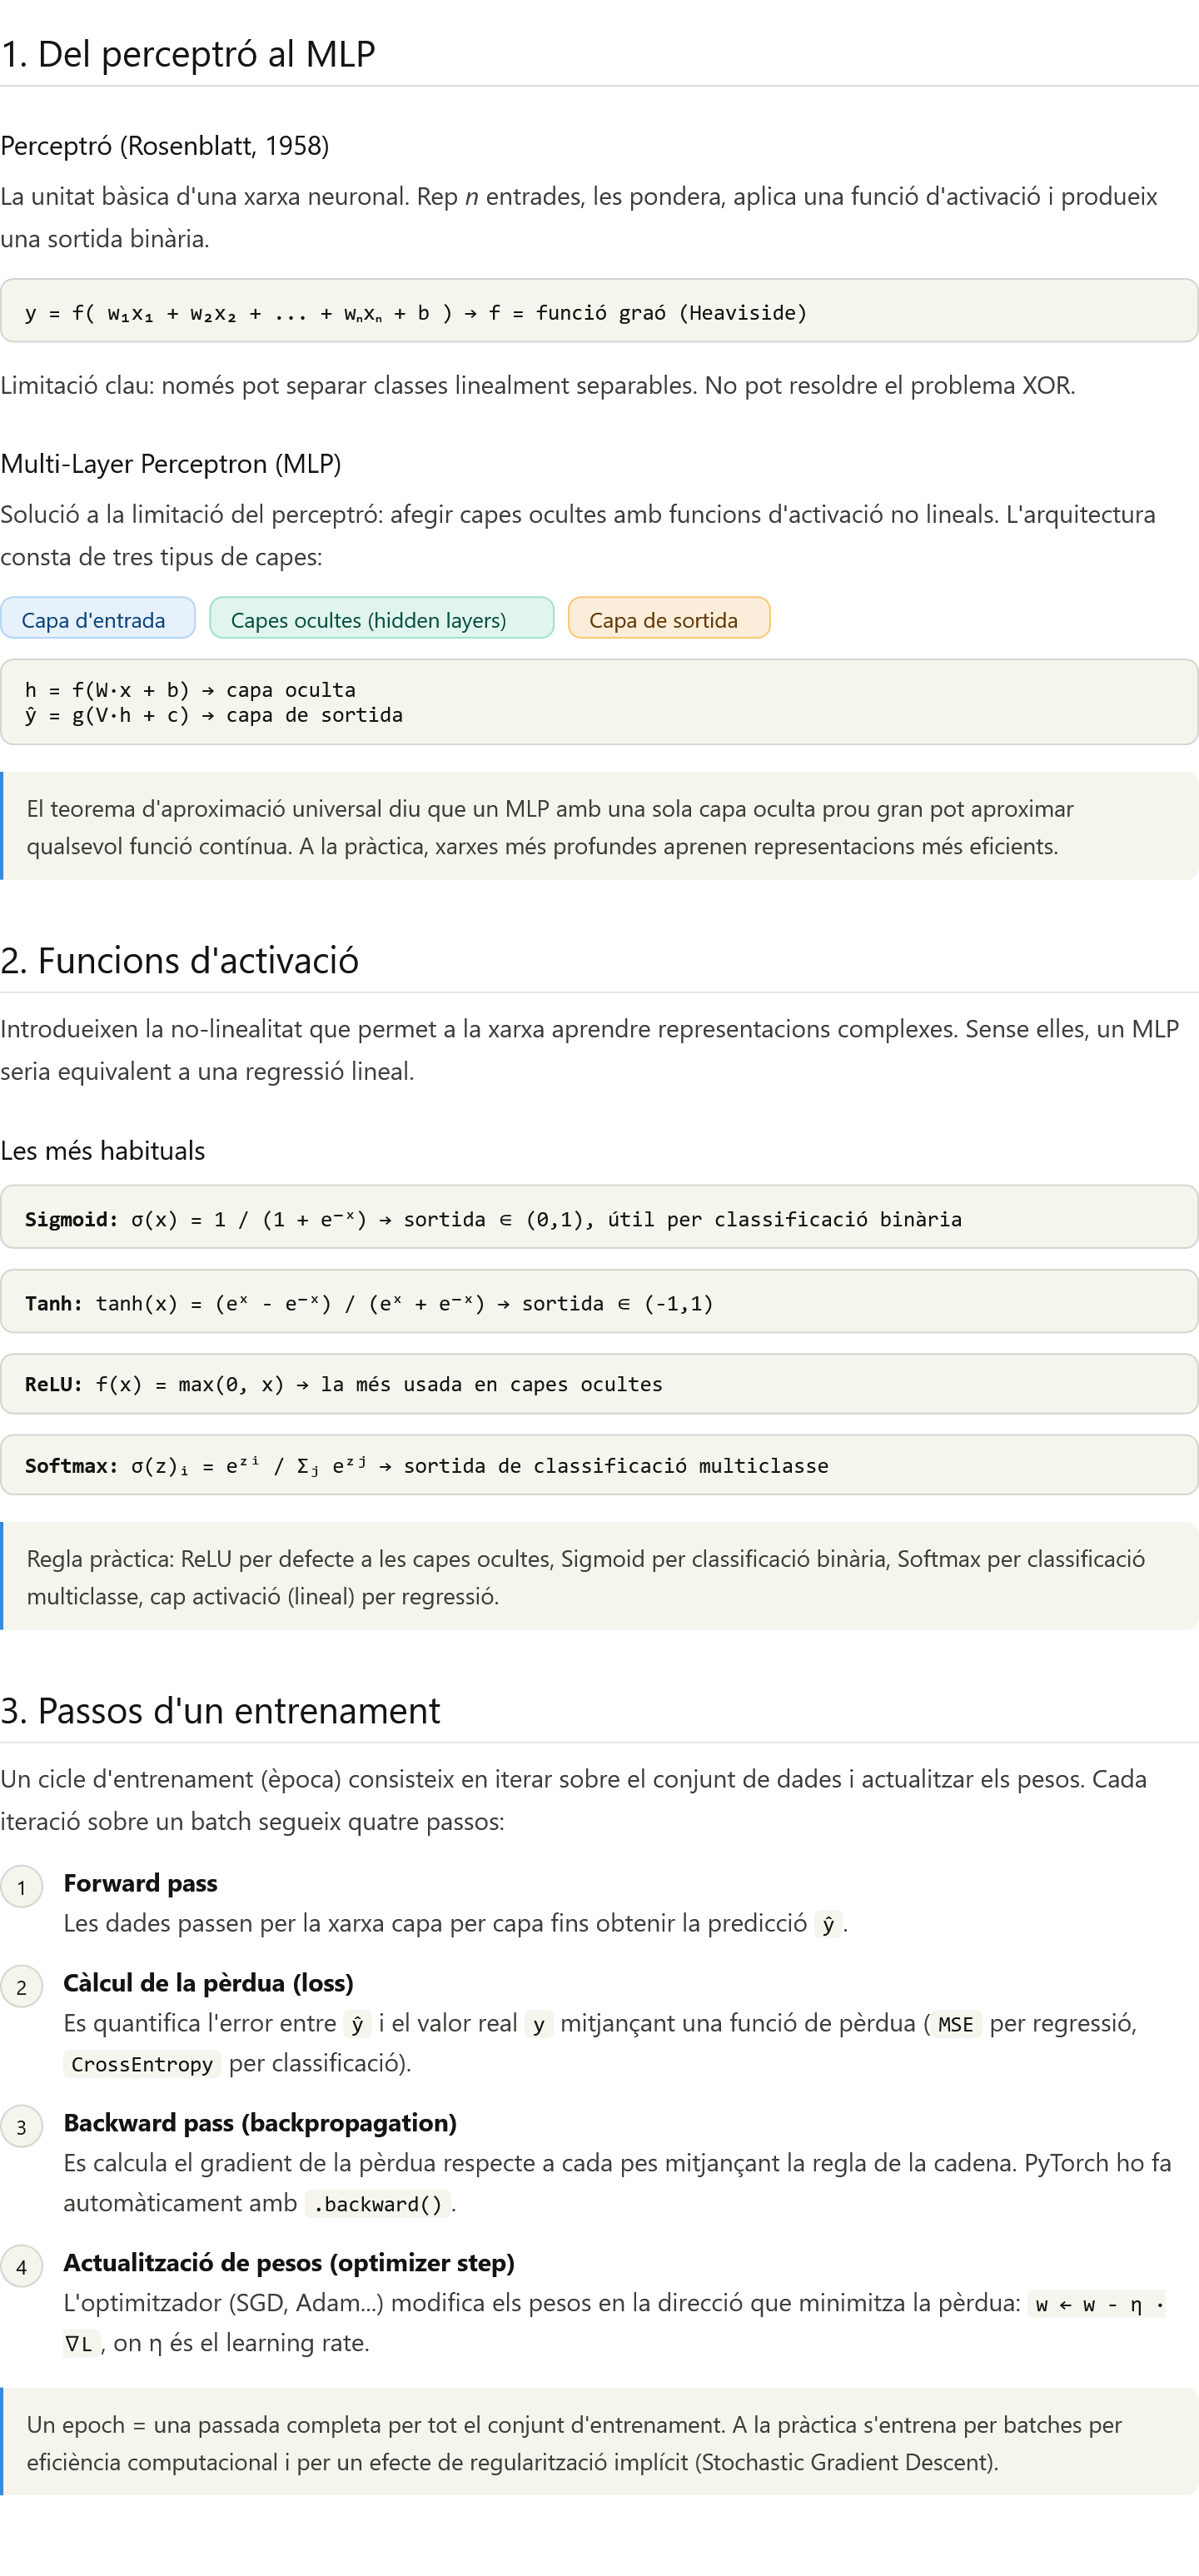